## Cơ sở lý thuyết Granger Causality cho dữ liệu COVID đa biến

### 1. Granger Causality là gì?
Granger Causality là một khái niệm nhân quả theo nghĩa dự báo trong chuỗi thời gian. Nói ngắn gọn, biến $X$ được xem là Granger-gây ra biến $Y$ nếu thông tin quá khứ của $X$ giúp dự báo $Y$ tốt hơn một cách có ý nghĩa thống kê, ngay cả khi đã dùng thông tin quá khứ của chính $Y$.

Điểm cần lưu ý là Granger không khẳng định quan hệ nhân quả cơ chế tuyệt đối, mà đánh giá chiều ảnh hưởng theo thời gian trong năng lực dự báo.

### 2. Vì sao cần quan tâm khi dữ liệu có nhiều biến?
Với dữ liệu COVID đa biến, ta thường có các chuỗi như Confirmed, Deaths, Recovered theo thời gian. Trong bối cảnh này, phân tích Granger có vai trò quan trọng vì:

- Giúp nhận diện biến nào là biến dẫn dắt (leading indicator), biến nào là biến phản ứng.
- Giúp chọn đặc trưng cho mô hình dự báo có cơ sở hơn, thay vì đưa toàn bộ biến vào một cách cảm tính.
- Giúp xây dựng ma trận quan hệ có hướng giữa các biến, từ đó diễn giải hệ thống tốt hơn cho báo cáo và ra quyết định.

### 3. Ý nghĩa thực tiễn và tác động nếu không xử lý
Nếu bỏ qua bước phân tích nhân quả trong dữ liệu đa biến, hệ thống dự báo có thể gặp các vấn đề sau:

- Mô hình giữ được độ khớp ngắn hạn nhưng thiếu ổn định khi dữ liệu thay đổi giai đoạn.
- Dễ nhầm lẫn giữa tương quan và quan hệ dẫn dắt theo thời gian.
- Chọn sai biến quan trọng, làm tăng nhiễu, tăng độ phức tạp và giảm khả năng tổng quát hóa.
- Rủi ro diễn giải sai kết quả, từ đó dẫn đến quyết định vận hành hoặc chính sách không phù hợp.

### 4. Lý thuyết kiểm định Granger và giả thuyết $H_0$
Với bậc trễ $p$, ta so sánh hai mô hình:

Mô hình ràng buộc (chỉ dùng quá khứ của $Y$):
$$
Y_t = c + \sum_{i=1}^{p} \alpha_i Y_{t-i} + \varepsilon_t
$$

Mô hình đầy đủ (dùng quá khứ của $Y$ và $X$):
$$
Y_t = c + \sum_{i=1}^{p} \alpha_i Y_{t-i} + \sum_{i=1}^{p} \beta_i X_{t-i} + u_t
$$

Giả thuyết kiểm định:

- $H_0$: $\beta_1 = \beta_2 = ... = \beta_p = 0$, tức là $X$ không Granger-gây ra $Y$.
- $H_1$: tồn tại ít nhất một $\beta_i \ne 0$, tức là $X$ có Granger-gây ra $Y$.

Quy tắc kết luận:

- Nếu p-value < $\alpha$ (ví dụ 0.05), bác bỏ $H_0$.
- Khi đó, có bằng chứng thống kê rằng $X$ giúp dự báo $Y$ theo nghĩa Granger.

### 5. Ví dụ thực tế với bộ dữ liệu COVID
Một số ví dụ điển hình khi phân tích trên dữ liệu theo ngày:

- Confirmed -> Deaths: số ca xác nhận thường đi trước số ca tử vong một khoảng trễ nhất định, nên chuỗi Confirmed có thể giúp dự báo Deaths.
- Confirmed -> Recovered: số ca nhiễm tăng trước thường kéo theo số ca hồi phục tăng sau đó theo độ trễ điều trị.
- Deaths -> Confirmed: quan hệ ngược chiều này thường yếu hơn trong nhiều bối cảnh, vì Deaths thường là biến phản ứng muộn.

Trong thực nghiệm đa biến, kiểm định được chạy cho mọi cặp có hướng để tạo ma trận nhân quả. Từ ma trận đó, ta trực quan hóa thành đồ thị có hướng nhằm nhìn rõ biến nào đang dẫn dắt hệ thống theo thời gian.

### 6. Lưu ý khi áp dụng trong bài toán thực tế
Để kết quả kiểm định tin cậy hơn, cần chú ý:

- Chuỗi nên được xử lý tính dừng (ví dụ sai phân) trước khi kiểm định.
- Chọn bậc trễ hợp lý theo bối cảnh và độ dài dữ liệu.
- Kiểm định Granger chỉ phản ánh nhân quả theo nghĩa dự báo, cần kết hợp kiến thức miền để diễn giải đúng.

## Thực nghiệm Granger Causality trên dữ liệu COVID (US)

Phần này thực hiện kiểm định Granger trên dữ liệu COVID theo ngày, sử dụng các biến `Confirmed`, `Deaths`, `Recovered` sau sai phân bậc 1 để giảm xu hướng tích lũy và tăng tính phù hợp cho kiểm định chuỗi thời gian.

In [1]:
import os
import sys

import numpy as np
import pandas as pd

# Cho phép import module trong thư mục src/
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)

from statistic.test_time_series import GrangerCausalityTesting

CONFIG = {
    "data_path": "../data/time_series/time-series-19-covid-combined.csv",
    "region": "US",
    "time_col": "Date",
    "variables": ["Confirmed", "Deaths", "Recovered"],
    "max_lag": 7,
    "alpha": 0.05,
}

print("Cấu hình thực nghiệm:")
for k, v in CONFIG.items():
    print(f"- {k}: {v}")

Cấu hình thực nghiệm:
- data_path: ../data/time_series/time-series-19-covid-combined.csv
- region: US
- time_col: Date
- variables: ['Confirmed', 'Deaths', 'Recovered']
- max_lag: 7
- alpha: 0.05


In [2]:
# 1) Nạp dữ liệu COVID và gom theo ngày cho một khu vực
raw = pd.read_csv(CONFIG["data_path"])
raw[CONFIG["time_col"]] = pd.to_datetime(raw[CONFIG["time_col"]], errors="coerce")
raw = raw.dropna(subset=[CONFIG["time_col"], "Country/Region"] + CONFIG["variables"])

region_df = raw.loc[raw["Country/Region"] == CONFIG["region"]].copy()

daily_df = (
    region_df.groupby(CONFIG["time_col"], as_index=False)[CONFIG["variables"]]
    .sum()
    .sort_values(CONFIG["time_col"])
    .reset_index(drop=True)
)

# 2) Sai phân bậc 1 để giảm xu hướng tích lũy (cải thiện tính dừng)
stationary_df = daily_df[[CONFIG["time_col"]] + CONFIG["variables"]].copy()
stationary_df[CONFIG["variables"]] = stationary_df[CONFIG["variables"]].diff()
stationary_df = stationary_df.dropna().reset_index(drop=True)

print(f"Số dòng sau gom theo ngày: {len(daily_df)}")
print(f"Số dòng sau sai phân và dropna: {len(stationary_df)}")
print(stationary_df.head(5).to_string(index=False))

Số dòng sau gom theo ngày: 270
Số dòng sau sai phân và dropna: 269
      Date  Confirmed  Deaths  Recovered
2020-01-23        0.0     0.0        0.0
2020-01-24        1.0     0.0        0.0
2020-01-25        0.0     0.0        0.0
2020-01-26        3.0     0.0        0.0
2020-01-27        0.0     0.0        0.0


In [3]:
# 3) Chạy Granger Causality cho bộ biến đã chọn
granger_tester = GrangerCausalityTesting(
    variables=CONFIG["variables"],
    max_lag=CONFIG["max_lag"],
    alpha=CONFIG["alpha"],
    test_stat="ssr_chi2test",
    verbose=False,
)

p_value_matrix, best_lag_matrix, binary_matrix = granger_tester.test(stationary_df)

print("=== Ma trận p-value (X -> Y) ===")
display(p_value_matrix.round(6))

print("=== Ma trận lag tối ưu (lag cho p-value nhỏ nhất) ===")
display(best_lag_matrix)

print("=== Ma trận nhân quả nhị phân (1 nếu p-value < alpha) ===")
display(binary_matrix)

significant_pairs = granger_tester.get_significant_pairs()
print(f"Số cặp nhân quả có ý nghĩa thống kê: {len(significant_pairs)}")
if significant_pairs:
    display(pd.DataFrame(significant_pairs))

=== Ma trận p-value (X -> Y) ===


,Confirmed,Deaths,Recovered
Confirmed,NaN,0.000000,0.00000
Deaths,0.00000,NaN,0.24144
Recovered,0.00003,0.001151,NaN


=== Ma trận lag tối ưu (lag cho p-value nhỏ nhất) ===


,Confirmed,Deaths,Recovered
Confirmed,NaN,4.0,1.0
Deaths,4.0,NaN,1.0
Recovered,1.0,6.0,NaN


=== Ma trận nhân quả nhị phân (1 nếu p-value < alpha) ===


,Confirmed,Deaths,Recovered
Confirmed,0,1,1
Deaths,1,0,0
Recovered,1,1,0


Số cặp nhân quả có ý nghĩa thống kê: 5


,cause,effect,p_value,best_lag
0,Confirmed,Recovered,1.300599e-21,1
1,Confirmed,Deaths,5.740065e-16,4
2,Deaths,Confirmed,2.424593e-14,4
3,Recovered,Confirmed,2.987037e-05,1
4,Recovered,Deaths,1.150585e-03,6


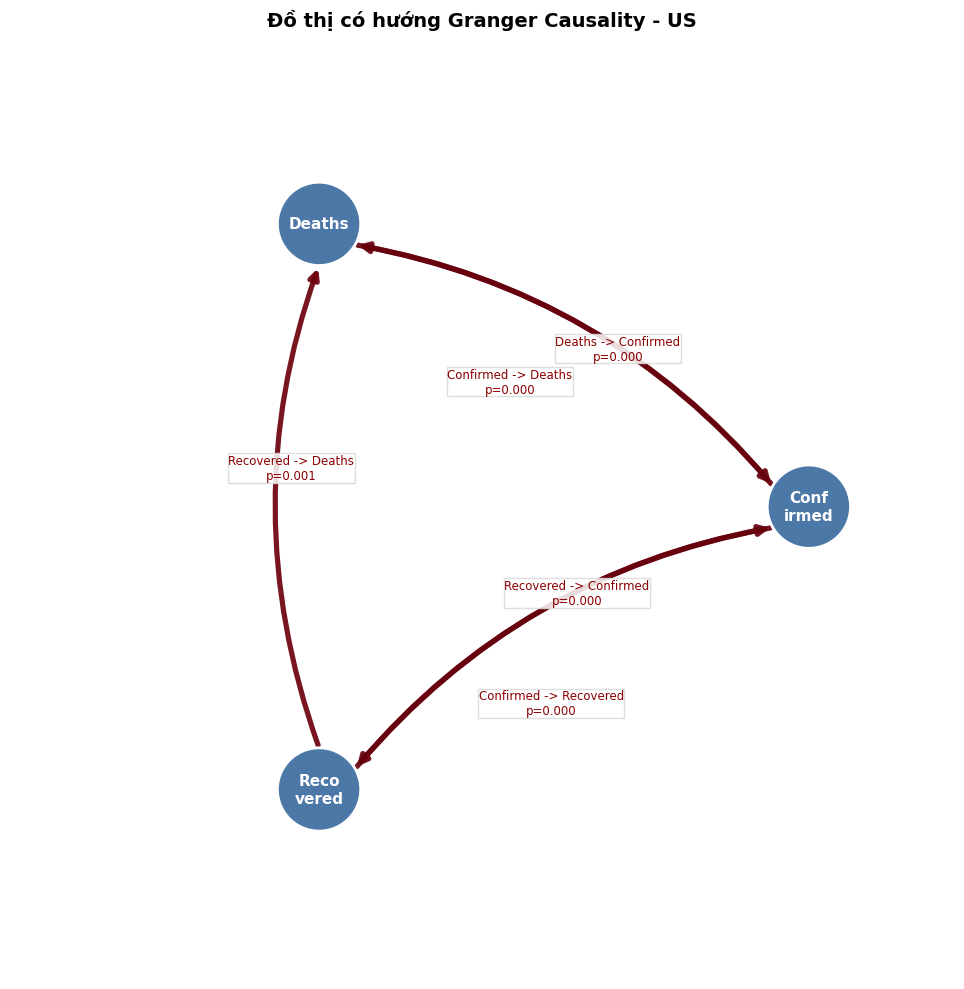

In [4]:
# 4) Trực quan hóa ma trận nhân quả bằng đồ thị có hướng
granger_tester.visualize_directed_graph(
    title=f"Đồ thị có hướng Granger Causality - {CONFIG['region']}",
    save_path=None,
    show_edge_labels=True,
)